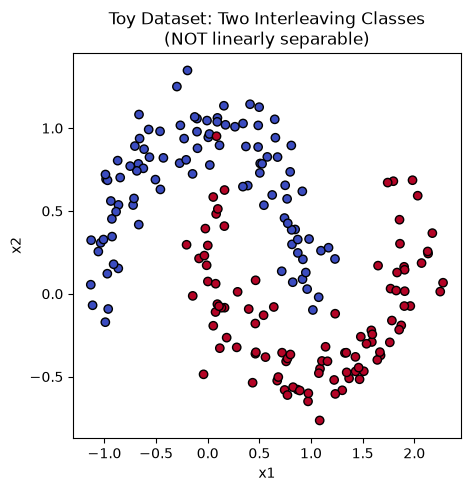

X shape: (200, 2)
y shape: (200, 1)


In [4]:
# ============================================
# Phase 2 — Day 14: Neural Network Fundamentals
# Building a network from scratch in NumPy (no PyTorch yet)
# ============================================

import numpy as np 
import matplotlib.pyplot as plt 
np.random.seed(42)                   # reproducibility
# ---- Toy dataset: 2D points, 2 classes, NOT linearly separable ----
# (a "moons" style dataset -- forces the network to actually need
#  a nonlinearity, a straight line genuinely can't separate this)
def make_moons(n_samples = 200 , noise = 0.15):
    n = n_samples // 2 
    theta1 = np.linspace(0, np.pi, n)
    x1 = np.stack([np.cos(theta1), np.sin(theta1)], axis = 1)
    theta2 = np.linspace(0, np.pi, n)
    x2 = np.stack([1 - np.cos(theta2),1 - np.sin(theta2)- 0.5], axis = 1)
    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n), np.ones(n)])
    X += np.random.normal(scale = noise, size = X.shape)
    return X, y.reshape(-1, 1)

X, y = make_moons()

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k')
plt.title('Toy Dataset: Two Interleaving Classes\n(NOT linearly separable)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

print(f"X shape: {X.shape}")  # (200, 2) -- 200 points, 2 features each
print(f"y shape: {y.shape}")  # (200, 1) -- 200 labels, 0 or 1

In [5]:
def init_params(input_dim = 2 , hidden_dim =4, output_dim =1):
    # Small random weights -- NOT zeros (would break symmetry, as discussed)
    # Scaled down (*0.5) to keep initial activations in a reasonable range
    W1 = np.random.randn(input_dim, hidden_dim) * 0.5 
    b1 = np.zeros((1, hidden_dim))
    W2 = np.random.randn(hidden_dim, output_dim) * 0.5
    b2 = np.zeros((1,output_dim))
    return W1,b1,W2,b2

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def forward(X,W1,b1,W2,b2):
    z1 = X@ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    cache = (X, z1, a1, z2, a2)

    return a2, cache

W1,b1,W2,b2 = init_params()
predictions, cache = forward(X, W1, b1, W2, b2)

print(f"W1 shape: {W1.shape}  (input_dim=2 -> hidden_dim=4)")
print(f"W2 shape: {W2.shape}  (hidden_dim=4 -> output_dim=1)")
print(f"Predictions shape: {predictions.shape}")
print(f"First 5 predictions (untrained, should look ~random): \n{predictions[:5].ravel()}")    

W1 shape: (2, 4)  (input_dim=2 -> hidden_dim=4)
W2 shape: (4, 1)  (hidden_dim=4 -> output_dim=1)
Predictions shape: (200, 1)
First 5 predictions (untrained, should look ~random): 
[0.49747953 0.49898244 0.49710365 0.49803381 0.49903825]


In [7]:
# ============================================
# Loss function (binary cross-entropy) + backpropagation
# ============================================

def compute_loss(y_true, y_pred):
    # Binary cross-entropy -- standard loss for 0/1 classification
    # Small epsilon avoids log(0) which would be -infinity
    eps= 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

def backward(y_true, cache, W2):
    X, z1, a1, z2, a2 = cache 
    m = X.shape[0]
    
    # --- Output layer gradients ---
    # dL/dz2 -- for sigmoid + binary cross-entropy, this combination
    # simplifies beautifully to just (prediction - truth). This is a
    # well-known calculus result, not a coincidence.
    dz2 = a2 - y_true                                   # (200,1)
    dW2 = (a1.T @dz2) / m                               # (4,200) @ (200,1) -> (4,1)
    db2 = np.sum(dz2, axis=0, keepdims= True) / m       
    
    # --- Hidden layer gradients (this is the actual "backward propagation" step) ---
    # Chain rule: how much did hidden layer activations contribute to the error?
    da1 = dz2 @ W2.T                                    # (200,1) @ (1,4) -> (200,4)
    dz1 = da1 * (z1 > 0)                                # ReLU derivative: 1 where z1>0, else 0
    dW1 = (X.T @ dz1) / m                               # (2,200) @ (200,4) -> (2,4)
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    
    return dW1,db1, dW2, db2
    
loss = compute_loss(y, predictions)
dW1, db1, dW2, db2 = backward(y, cache, W2)

print(f"Initial loss (untrained): {loss:.4f}")
print(f"(Random 2-class guessing should give loss around {-np.log(0.5):.4f})")
print()
print(f"dW1 shape: {dW1.shape}, dW2 shape: {dW2.shape}")
print(f"Sample dW2 values: {dW2.ravel()}")
 

Initial loss (untrained): 0.7056
(Random 2-class guessing should give loss around 0.6931)

dW1 shape: (2, 4), dW2 shape: (4, 1)
Sample dW2 values: [ 0.05259967  0.0608471  -0.02957107 -0.00856629]


Epoch    0  Loss: 0.8334  Accuracy: 49.50%
Epoch  500  Loss: 0.3014  Accuracy: 85.00%
Epoch 1000  Loss: 0.3014  Accuracy: 85.00%
Epoch 1500  Loss: 0.3013  Accuracy: 85.00%
Epoch 2000  Loss: 0.3013  Accuracy: 85.00%
Epoch 2500  Loss: 0.3013  Accuracy: 85.00%


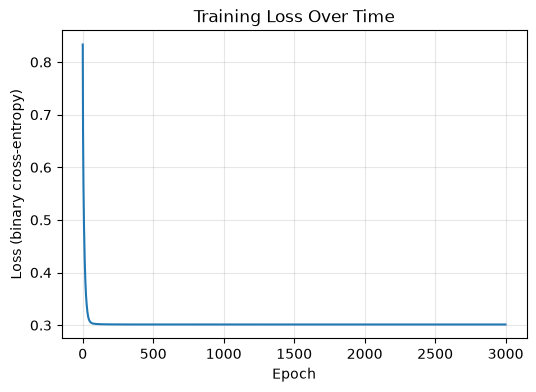


Final accuracy: 85.00%


In [10]:
# ============================================
# Training loop: forward -> loss -> backward -> update weights
# Repeat until the network actually learns the crescent shapes
# ============================================

# Reinitialize fresh weights (clean start )
W1, b1, W2, b2 = init_params()

learning_rate = 0.5 
epochs = 3000
loss_history = []

for epoch in range(epochs):
    # Forwards pass 
    predictions, cache = forward(X,W1,b1,W2,b2)
    loss = compute_loss(y, predictions)
    loss_history.append(loss)

    #backward pass 
    dW1,db1,dW2,db2 = backward(y,cache, W2)

    # Gradient descent update: move weights AGAINST the gradient
    # (gradient points toward increasing loss, so we subtract it)
    W1 -= learning_rate * dW1 
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 500 == 0:
          # Accuracy: threshold predictions at 0.5 and compare to true labels
        acc = np.mean((predictions > 0.5) == y)
        print(f"Epoch {epoch:4d}  Loss: {loss:.4f}  Accuracy: {acc:.2%}")

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (binary cross-entropy)')
plt.title('Training Loss Over Time')
plt.grid(alpha=0.3)
plt.show()

final_acc = np.mean((predictions > 0.5) == y)
print(f"\nFinal accuracy: {final_acc:.2%}")

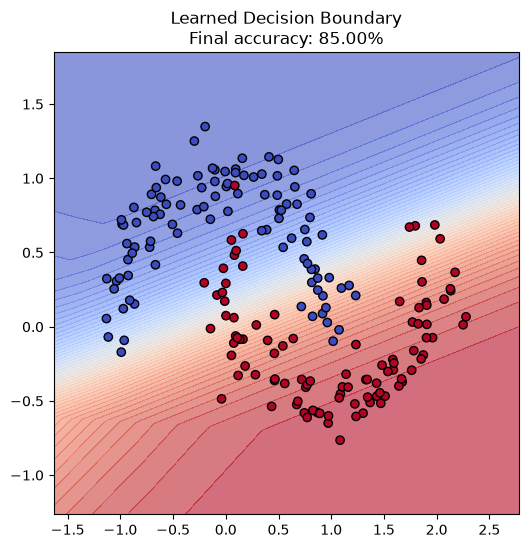

Hidden neuron activation stats:
  Neuron 0: active on 0.0% of samples (mean activation: 0.0000)
  Neuron 1: active on 100.0% of samples (mean activation: 1.5568)
  Neuron 2: active on 99.5% of samples (mean activation: 1.4365)
  Neuron 3: active on 0.0% of samples (mean activation: 0.0000)


In [13]:
# ============================================
# Diagnose the plateau: what decision boundary did it actually learn?
# And are any hidden neurons "dead" (always outputting 0)?
# ============================================

# --- Plot decision boundary ---

xx ,yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200), 
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_preds, _ = forward(grid, W1, b1, W2, b2)
grid_preds = grid_preds.reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, grid_preds, levels= 50, cmap = 'coolwarm',alpha = 0.6)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k')
plt.title(f'Learned Decision Boundary\nFinal accuracy: {final_acc:.2%}')
plt.show()

# --- Check hidden layer health: is any neuron dead (always outputs 0)? ---
_, cache_check = forward(X, W1, b1, W2, b2)
_,z1_check,a1_check, _, _ = cache_check

print("Hidden neuron activation stats:")
for i in range(a1_check.shape[1]):
    active_fraction = np.mean(a1_check[:, i] > 0)
    print(f"  Neuron {i}: active on {active_fraction:.1%} of samples "
          f"(mean activation: {a1_check[:, i].mean():.4f})")

Epoch    0  loss: 0.6234  Accuracy: 50.00%
Epoch  500  loss: 0.1187  Accuracy: 97.00%
Epoch 1000  loss: 0.0458  Accuracy: 99.50%
Epoch 1500  loss: 0.0317  Accuracy: 99.50%
Epoch 2000  loss: 0.0259  Accuracy: 99.50%
Epoch 2500  loss: 0.0228  Accuracy: 99.50%

Final Accuracy : 99.50%


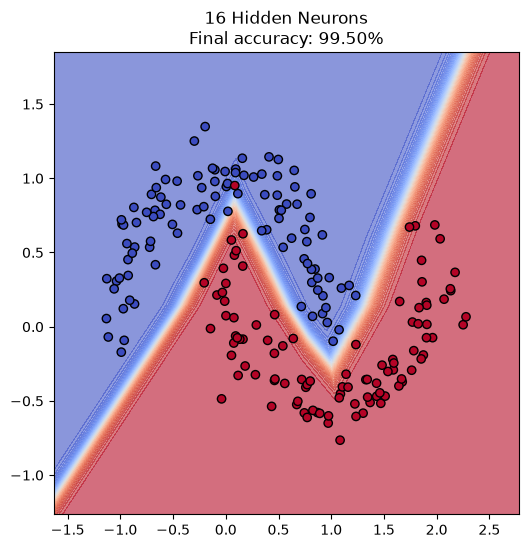

In [15]:
# More capacity: even if 2-3 neurons die, more survive to do useful work

W1, b1, W2, b2 = init_params(hidden_dim=16)

learning_rate = 0.5 
epochs = 3000 
loss_history = []

for epoch in range(epochs):
    predictions , cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, predictions )
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(y, cache, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 500 == 0: 
        acc = np.mean((predictions > 0.5) == y) 
        print(f"Epoch {epoch:4d}  loss: {loss:.4f}  Accuracy: {acc:.2%}" )

final_acc = np.mean((predictions > 0.5) == y )
print(f"\nFinal Accuracy : {final_acc :.2%}")

grid_preds, _ = forward(grid, W1, b1, W2, b2)
grid_preds = grid_preds.reshape(xx.shape)
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, grid_preds, levels=50, cmap='coolwarm', alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k')
plt.title(f'16 Hidden Neurons\nFinal accuracy: {final_acc:.2%}')
plt.show()

Epoch    0  Loss: 0.7666  Accuracy: 50.00%
Epoch  500  Loss: 0.2670  Accuracy: 85.50%
Epoch 1000  Loss: 0.2646  Accuracy: 85.50%
Epoch 1500  Loss: 0.2628  Accuracy: 85.50%
Epoch 2000  Loss: 0.2621  Accuracy: 86.00%
Epoch 2500  Loss: 0.2617  Accuracy: 86.00%

Final accuracy: 86.00%

Hidden neuron activation stats:
  Neuron 0: positive (fully active) on 28.0% of samples
  Neuron 1: positive (fully active) on 19.5% of samples
  Neuron 2: positive (fully active) on 74.0% of samples
  Neuron 3: positive (fully active) on 96.5% of samples


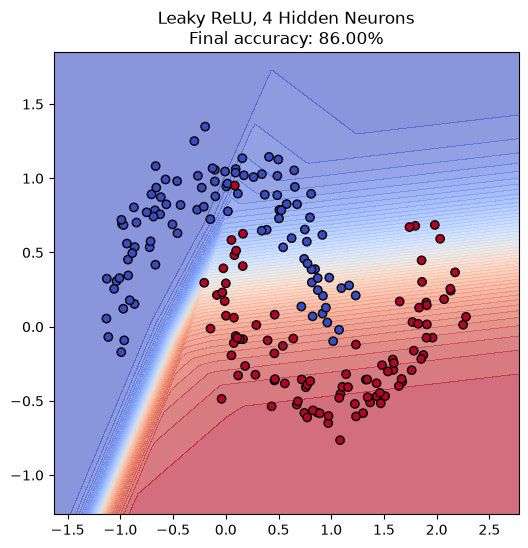

In [18]:
# ============================================
# Leaky ReLU fix -- back to the ORIGINAL 4-neuron network,
# to isolate whether the activation function alone fixes dying ReLU
# ============================================

def leaky_relu(z, alpha = 0.01):
    return np.where(z > 0 ,z, alpha *z)

def leaky_relu_deriv(z, alpha = 0.01):
    return np.where(z > 0, 1 , alpha)

def forward_leaky(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1 
    a1 = leaky_relu(z1)
    z2 = a1 @ W2 + b2 
    a2 = sigmoid(z2)
    cache = (X, z1, a1, z2, a2)
    return a2 , cache 

def backward_leaky(y_true, cache, W2):
    X, z1, a1, z2, a2 = cache
    m = X.shape[0]
    dz2 = a2 - y_true
    dW2 = (a1.T @ dz2) / m
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    da1 = dz2 @ W2.T
    dz1 = da1 * leaky_relu_deriv(z1)   # <-- only change from before
    dW1 = (X.T @ dz1) / m
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2

# Back to the ORIGINAL small hidden_dim=4 -- same capacity that failed before
W1, b1, W2, b2 = init_params(hidden_dim=4)

learning_rate = 0.5
epochs = 3000
loss_history = []

for epoch in range(epochs):
    predictions, cache = forward_leaky(X, W1, b1, W2, b2)
    loss = compute_loss(y, predictions)
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward_leaky(y, cache, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 500 == 0:
        acc = np.mean((predictions > 0.5) == y)
        print(f"Epoch {epoch:4d}  Loss: {loss:.4f}  Accuracy: {acc:.2%}")

final_acc = np.mean((predictions > 0.5) == y)
print(f"\nFinal accuracy: {final_acc:.2%}")

# Check: are any neurons still "dead" (near-zero activation on every sample)?
_, cache_check = forward_leaky(X, W1, b1, W2, b2)
_, z1_check, a1_check, _, _ = cache_check
print("\nHidden neuron activation stats:")
for i in range(a1_check.shape[1]):
    active_fraction = np.mean(z1_check[:, i] > 0)
    print(f"  Neuron {i}: positive (fully active) on {active_fraction:.1%} of samples")

grid_preds, _ = forward_leaky(grid, W1, b1, W2, b2)
grid_preds = grid_preds.reshape(xx.shape)
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, grid_preds, levels=50, cmap='coolwarm', alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='coolwarm', edgecolors='k')
plt.title(f'Leaky ReLU, 4 Hidden Neurons\nFinal accuracy: {final_acc:.2%}')
plt.show()